### Part 2: Preparations for a New Search Strategy for Anomalous Events

Usage of sliding windows to filter temporal fluctuations in the reconstruction error.
Additional heuristic filtering to reduce the search space resulting in detection events.

In [ ]:
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions.preprocessing import PreprocessingStep5
from helperfunctions.detection import Part2 as p2
from helperfunctions.detection import NBM_COLS
import pandas as pd
from pathlib import Path
import os
from glob import glob
#%matplotlib widget

pd.set_option("display.max_columns", None)

In [ ]:
cfg_part2 = hfn.TrainConfig(config_name="part2", choose_val_set=2)


{
  "config_name": "part2",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearin

In [ ]:
test_eval_file = glob(os.path.join(ic.PATH_PART2_EVAL_TEST, "*.csv")) [0]
test_eval_df = pd.read_csv(test_eval_file)

display(test_eval_df.head())

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C),RE_Generator RPM (RPM),RE_Hub temperature (°C),RE_Motor current axis 1 (A),RE_Motor current axis 2 (A),RE_Motor current axis 3 (A),RE_Nacelle ambient temperature (°C),RE_Nacelle position (°),RE_Nacelle temperature (°C),RE_Power (kW),RE_Rotor bearing temp (°C),RE_Rotor speed (RPM),RE_Stator temperature 1 (°C),RE_Temp. top box (°C),RE_Temperature motor axis 1 (°C),RE_Temperature motor axis 2 (°C),RE_Temperature motor axis 3 (°C),RE_Vane position 1+2 (°),RE_Wind direction (°),RE_Wind speed (m/s),RE_Blade angle (pitch position) A (°),RE_Blade angle (pitch position) B (°),RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1588306200000000001,2020-05-01 04:10:00,1,0.021798,0.008148,0.094487,0.020666,0.021166,0.002876,0.011175,0.003134,0.002139,0.083261,0.000055,0.000006,0.006936,0.027010,2.388245e-01,0.002420,0.000163,0.001425,0.001798,1.648817e-06,1.111275e-02,0.002902,0.002989,0.003100,0.018406,0.000058,0.000525,0.002179,0.002669,0.002781,0.001968,0.000169,0.004524,0.000044,0.000239,0.012340,0.000073,0.000367,0.236192
1,1588306200000000002,2020-05-01 04:10:00,2,0.026611,0.005555,0.147881,0.003152,0.005707,0.000037,0.000812,0.001665,0.000005,0.008374,0.000661,0.001424,0.000864,0.001743,2.390153e-01,0.006600,0.005054,0.180388,0.000170,2.252205e-03,1.640601e-02,0.002016,0.003590,0.003878,0.027006,0.000309,0.002825,0.000692,0.000909,0.000992,0.014479,0.004077,0.037727,0.014320,0.001727,0.014470,0.003942,0.013449,0.237053
2,1588306200000000004,2020-05-01 04:10:00,4,0.002452,0.000042,0.000007,0.002139,0.001538,0.000092,0.000897,0.000340,0.000293,0.026001,0.000186,0.000001,0.001525,0.000315,9.567735e-05,0.038999,0.002810,0.001857,0.000648,1.571099e-09,1.076651e-07,0.000094,0.000615,0.000009,0.000876,0.000004,0.001630,0.000468,0.000294,0.000284,0.000529,0.000318,0.003309,0.000072,0.000651,0.005969,0.000130,0.000011,0.000130
3,1588306200000000005,2020-05-01 04:10:00,5,0.013120,0.005832,0.035099,0.013446,0.022986,0.000044,0.008692,0.004631,0.000002,0.000229,0.014190,0.004403,0.012072,0.003371,4.101939e-05,0.005850,0.001402,0.003673,0.000112,9.969746e-04,5.928122e-05,0.000172,0.000108,0.000001,0.000500,0.249002,0.008641,0.000214,0.000377,0.000418,0.002332,0.004244,0.015442,0.001185,0.018634,0.051762,0.007190,0.001146,0.000083
4,1588306200000000006,2020-05-01 04:10:00,6,0.013144,0.000221,0.043485,0.000567,0.001858,0.005117,0.000530,0.010470,0.001455,0.000081,0.000861,0.000829,0.000894,0.003858,2.060028e-08,0.005266,0.004495,0.000031,0.000075,1.441789e-03,1.015547e-02,0.047146,0.044287,0.046548,0.017712,0.236755,0.001082,0.001290,0.001459,0.000232,0.000188,0.000374,0.001174,0.001621,0.000152,0.001344,0.002955,0.003236,0.000237


In [ ]:
test_eval_clean = p2.drop_imputations(test_eval_df)

In [ ]:
imp_files = Path(ic.PATH_IMPUTED).glob("*.csv")

wts : list[pd.DataFrame] = []

for fp in imp_files:
    df_wt  =pd.read_csv(fp, parse_dates=[ic.TS_COL])
    df_wt[ic.TS_COL] = pd.to_datetime(df_wt[ic.TS_COL], errors="raise")
    df_wt = df_wt.sort_values(ic.TS_COL)
    df_wt_test = df_wt[(df_wt[ic.TS_COL] >= cfg_part2.test_start_time) & (df_wt[ic.TS_COL] <= cfg_part2.test_end_time)]
    wts.append(df_wt)
    
raw_test = pd.concat(wts, axis=0, ignore_index=True)
raw_test = raw_test.sort_values([ic.WT_ID, ic.TS_COL]).reset_index(drop=True)

raw_test = p2.drop_imputations(raw_test)
os.makedirs(ic.PATH_PART2_RAW_TEST, exist_ok=True)
raw_test.to_csv(ic.PATH_PART2_RAW_TEST / "raw_test.csv")
display(raw_test)

,WT_ID,Ambient temperature (converter) (°C),Date and time,Drive train acceleration (mm/ss),Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Gearbox speed (RPM),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Generator RPM (RPM),Hub temperature (°C),Motor current axis 1 (A),Motor current axis 2 (A),Motor current axis 3 (A),Nacelle ambient temperature (°C),Nacelle position (°),Nacelle temperature (°C),Power (kW),Rotor bearing temp (°C),Rotor speed (RPM),Stator temperature 1 (°C),Temp. top box (°C),Temperature motor axis 1 (°C),Temperature motor axis 2 (°C),Temperature motor axis 3 (°C),Vane position 1+2 (°),Wind direction (°),Wind speed (m/s),Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°),Front bearing temperature (°C),Gear oil inlet temperature (°C),Gear oil temperature (°C),Rear bearing temperature (°C),Tower Acceleration X (mm/ss),Tower Acceleration Y (mm/ss),Transformer cell temperature (°C),Transformer temperature (°C),Yaw bearing angle (°)
0,1,8.886364,2018-04-05 13:50:00,84.215630,222.195496,614.294067,1775.618774,35.227272,38.127274,1774.221191,12.000000,-2.397506e-01,-0.539216,0.579323,7.145454,265.389313,16.813637,1050.261230,28.177273,16.867664,61.836365,23.695456,48.168182,51.031818,48.636364,-4.109046,259.431061,8.432441,0.000000,0.000000,0.000000,71.868179,49.604546,58.040909,63.022728,44.158005,16.394218,11.000000,43.190907,265.389313
1,1,9.020000,2018-04-05 14:00:00,83.337074,211.881287,588.308411,1716.233887,37.028332,39.248333,1715.009521,12.000000,2.125816e-01,0.021242,1.167647,7.320000,258.657104,17.543333,864.163757,28.320000,16.295387,64.084999,23.710001,44.291332,47.303333,44.805668,-3.752453,253.765579,8.332128,0.018000,0.018000,0.017333,72.098335,50.856667,58.200001,63.035000,46.899048,26.877043,11.300000,43.434998,258.657104
2,1,9.300000,2018-04-05 14:10:00,92.407433,200.020737,552.660828,1715.237671,37.798275,39.627586,1714.197266,12.000000,-3.735633e-01,-0.516058,0.545639,7.410345,252.218536,14.820689,888.429932,28.382759,16.295769,64.739655,23.844828,39.965519,42.463104,40.479309,3.593682,254.095566,8.278221,0.000000,0.000000,0.000000,73.525864,55.715519,59.391380,63.956898,51.394279,19.161951,11.413793,43.384483,252.218536
3,1,9.216667,2018-04-05 14:20:00,90.661583,267.993591,763.333496,1707.441406,36.098331,38.843334,1706.402832,12.000000,-2.349674e-01,0.023529,0.651307,7.241667,246.889282,13.206667,881.109497,28.308334,16.210365,61.603333,23.671667,37.166668,39.389668,37.599998,-2.304303,244.534927,8.351465,0.002333,0.002000,0.002667,71.198334,36.943333,57.778332,62.551666,51.467808,27.534857,11.413334,43.491665,246.889282
4,1,9.220000,2018-04-05 14:30:00,85.227211,254.927795,709.947754,1726.104004,34.810001,37.741665,1724.966187,12.033667,-4.901962e-01,-0.490196,0.490196,7.216667,240.986282,14.205000,861.777832,28.326666,16.406225,59.398335,23.498333,35.400002,37.400002,35.833332,6.911681,248.549179,8.123881,0.000000,0.000000,0.000000,67.166664,38.938332,55.606667,59.930000,41.149757,22.395346,11.423333,43.511665,240.994415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3172311,15,6.630000,2022-12-31 13:30:00,3.799413,-0.295109,10.967880,0.211333,25.336666,24.000000,-0.784845,12.000000,-1.192093e-07,0.487255,-0.490196,5.288333,165.898590,14.535000,-0.126973,18.666667,0.000000,32.650000,22.814999,22.000000,21.868000,21.000000,-105.859571,61.170082,1.494738,44.990002,44.990002,44.990002,32.785000,31.936667,36.368334,35.303334,3.503624,3.982784,8.598333,35.765000,165.898590
3172312,15,6.643333,2022-12-31 13:40:00,3.811923,0.181481,14.274103,1.230168,25.035000,23.843333,-0.834295,12.000000,-1.192093e-07,0.490196,-0.490196,5.051667,165.898590,14.273333,-0.182813,18.561667,0.000000,32.323334,22.626667,22.000000,21.580000,21.000000,-73.903604,40.586551,1.736062,44.990002,44.990002,44.99000

#### Powercurve filtering

In [ ]:
pstep = PreprocessingStep5()
df_pc = pstep._prepare_power_curve()

margin = 300
power_min = 200

frames_filtered: list[pd.DataFrame] = []

for wt_id, df_wt in raw_test.groupby(ic.WT_ID, sort=False):
    df_wt = df_wt.copy()
    df_wt[ic.TS_COL] = pd.to_datetime(df_wt[ic.TS_COL], errors="raise")
    
    df_wt = df_wt.sort_values(ic.TS_COL).set_index(ic.TS_COL)
    
    mask = pstep._nb_filtering_by_powercurve(
        df=df_wt,
        df_pc=df_pc,
        max_abs_margin_kw=300.0
    ).astype(bool)
    
    power_vals = pd.to_numeric(df_wt["Power (kW)"], errors="coerce")
    pc_mask = mask & (power_vals >= power_min)
    
    ts_keep = df_wt.index.to_numpy()[pc_mask.to_numpy()]
    keys = pd.DataFrame({ic.WT_ID: int(wt_id), ic.TS_COL: ts_keep})
    frames_filtered.append(keys)

pc_keys_df = (
    pd.concat(frames_filtered, axis=0, ignore_index=True)
    .sort_values([ic.WT_ID, ic.TS_COL])
    .reset_index(drop=True)
)

display(pc_keys_df)
print(len(pc_keys_df))

,WT_ID,Date and time
0,1,2018-04-05 13:50:00
1,1,2018-04-05 14:00:00
2,1,2018-04-05 14:10:00
3,1,2018-04-05 14:20:00
4,1,2018-04-05 14:30:00
...,...,...
1883471,15,2022-12-31 04:20:00
1883472,15,2022-12-31 04:30:00
1883473,15,2022-12-31 04:40:00
1883474,15,2022-12-31 04:50:00


1883476


In [ ]:
test_eval_pc_filtered = (
    test_eval_clean
    .merge(pc_keys_df, on=[ic.WT_ID, ic.TS_COL], how="inner", validate="one_to_one")
    .sort_values([ic.WT_ID, ic.TS_COL])
    .reset_index(drop=True)
)

display(test_eval_pc_filtered.head())
print(len(test_eval_pc_filtered))

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C),RE_Generator RPM (RPM),RE_Hub temperature (°C),RE_Motor current axis 1 (A),RE_Motor current axis 2 (A),RE_Motor current axis 3 (A),RE_Nacelle ambient temperature (°C),RE_Nacelle position (°),RE_Nacelle temperature (°C),RE_Power (kW),RE_Rotor bearing temp (°C),RE_Rotor speed (RPM),RE_Stator temperature 1 (°C),RE_Temp. top box (°C),RE_Temperature motor axis 1 (°C),RE_Temperature motor axis 2 (°C),RE_Temperature motor axis 3 (°C),RE_Vane position 1+2 (°),RE_Wind direction (°),RE_Wind speed (m/s),RE_Blade angle (pitch position) A (°),RE_Blade angle (pitch position) B (°),RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1588356000000000001,2020-05-01 18:00:00,1,0.008959,1.621195e-03,0.096087,0.032412,0.034532,0.000201,0.001335,0.001915,0.000502,0.010860,0.006547,0.003555,0.000133,0.075592,0.002355,0.001629,0.006480,0.001081,0.000643,0.000131,0.000032,0.000504,0.000236,0.000484,0.016158,0.001336,0.004934,0.002099,0.002553,0.002654,0.000174,0.000200,0.003215,0.000504,0.007060,0.015160,0.002317,0.000637,0.002556
1,1588356600000000001,2020-05-01 18:10:00,1,0.007518,1.772346e-03,0.101853,0.022803,0.025514,0.000901,0.004737,0.005222,0.001369,0.010705,0.005809,0.004543,0.000077,0.031577,0.000201,0.000742,0.008115,0.000877,0.001603,0.000681,0.000009,0.000212,0.001716,0.000712,0.009541,0.000011,0.000317,0.002241,0.002709,0.002727,0.001201,0.000200,0.006016,0.004210,0.005352,0.012390,0.006405,0.000387,0.000246
2,1588357200000000001,2020-05-01 18:20:00,1,0.009232,2.947177e-07,0.104060,0.014188,0.016078,0.003631,0.006126,0.012897,0.002761,0.010391,0.003678,0.002124,0.001922,0.035694,0.000009,0.072479,0.000064,0.000605,0.002398,0.000323,0.000057,0.000304,0.001115,0.000468,0.015622,0.000070,0.001888,0.002196,0.002671,0.002787,0.000280,0.000382,0.005802,0.001479,0.003088,0.022705,0.000238,0.000197,0.000030
3,1588357800000000001,2020-05-01 18:30:00,1,0.007625,8.185777e-04,0.092362,0.016994,0.016553,0.003744,0.004117,0.008155,0.002780,0.010382,0.005329,0.003641,0.000059,0.031317,0.000231,0.029590,0.000075,0.000785,0.002519,0.000108,0.001119,0.000412,0.002036,0.001255,0.008228,0.000114,0.004097,0.002172,0.002638,0.002755,0.000139,0.000189,0.005222,0.000713,0.005787,0.022867,0.000022,0.000259,0.000169
4,1588362600000000001,2020-05-01 19:50:00,1,0.008033,2.149751e-04,0.093912,0.022221,0.019402,0.001434,0.001116,0.006571,0.000856,0.010879,0.014525,0.007175,0.000004,0.055281,0.000345,0.000903,0.000791,0.001745,0.000662,0.000386,0.000023,0.006084,0.010813,0.007426,0.000881,0.000148,0.001092,0.002017,0.002460,0.002576,0.000059,0.000129,0.003411,0.000573,0.003618,0.019554,0.005315,0.000402,0.000260


1022647


In [ ]:
det_points_ng = pd.read_csv(ic.PATH_PART2_DETECTIONS/ "det_points_no_gap.csv")

det_points_ng = det_points_ng[det_points_ng["Power (kW)"] >= 300]
display(det_points_ng)

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
3,6,2021-11-17 06:50:00,6.780597,337.755948
6,10,2020-08-28 17:40:00,9.870935,1227.676156
7,4,2021-12-02 01:40:00,10.975736,1373.680192
8,10,2020-12-29 04:40:00,8.521861,792.171306
10,10,2022-02-10 06:50:00,8.383355,829.243985
...,...,...,...,...
68793,12,2022-07-04 11:10:00,14.176776,1980.597274
68794,13,2022-06-09 20:40:00,9.196610,1159.906018
68796,13,2022-07-13 16:10:00,10.655390,1409.940090
68802,13,2022-07-07 01:20:00,7.600145,770.029235


In [ ]:
det_points_ng[ic.TS_COL] = pd.to_datetime(det_points_ng[ic.TS_COL])
det_points_ng = det_points_ng.merge(
    pc_keys_df,
    on=[ic.WT_ID, ic.TS_COL],
    how="inner",
    validate="one_to_one"
)
display(det_points_ng)

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,6,2021-11-17 06:50:00,6.780597,337.755948
1,10,2020-08-28 17:40:00,9.870935,1227.676156
2,10,2020-12-29 04:40:00,8.521861,792.171306
3,10,2022-02-10 06:50:00,8.383355,829.243985
4,10,2022-12-20 03:50:00,8.610380,972.138497
...,...,...,...,...
22444,12,2022-07-04 11:10:00,14.176776,1980.597274
22445,13,2022-06-09 20:40:00,9.196610,1159.906018
22446,13,2022-07-13 16:10:00,10.655390,1409.940090
22447,13,2022-07-07 01:20:00,7.600145,770.029235


In [ ]:
theta = p2.load_threshold_table()

   WT_ID    k     sigma  threshold   tp   fn     fp  precision  recall  \
0      1  1.0  0.029094    0.04219  7.0  1.0  236.0   0.028807   0.875   

         f1  FAR_per_day  latency_mean  
0  0.055777     1.594595    111.714286  


### Power Curve 

In [ ]:
pre_step5 = PreprocessingStep5()
df_pc = pre_step5._prepare_power_curve()
df_pc.head()

,power_norm
0.00,0.0
0.01,0.0
0.02,0.0
0.03,0.0
0.04,0.0


In [ ]:
cfg_part2 = hfn.TrainConfig(config_name="part2", choose_val_set=2)
test_start = cfg_part2.test_start_time
test_end = cfg_part2.test_end_time

wt_farm_df = pd.read_csv(ic.PATH_PART2_WT_FARM /  "wt_farm_pc_df.csv")
wt_farm_df[ic.TS_COL] = pd.to_datetime(wt_farm_df[ic.TS_COL])
wt_farm_df.head()

{
  "config_name": "part2",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearin

,WT_ID,Date and time,Wind speed (m/s),Power (kW)
0,1,2020-05-01 04:10:00,5.180120,154.845861
1,1,2020-05-01 04:20:00,4.917112,125.039087
2,1,2020-05-01 04:30:00,5.379890,151.489965
3,1,2020-05-01 04:40:00,4.659290,100.066924
4,1,2020-05-01 04:50:00,5.240885,117.778430


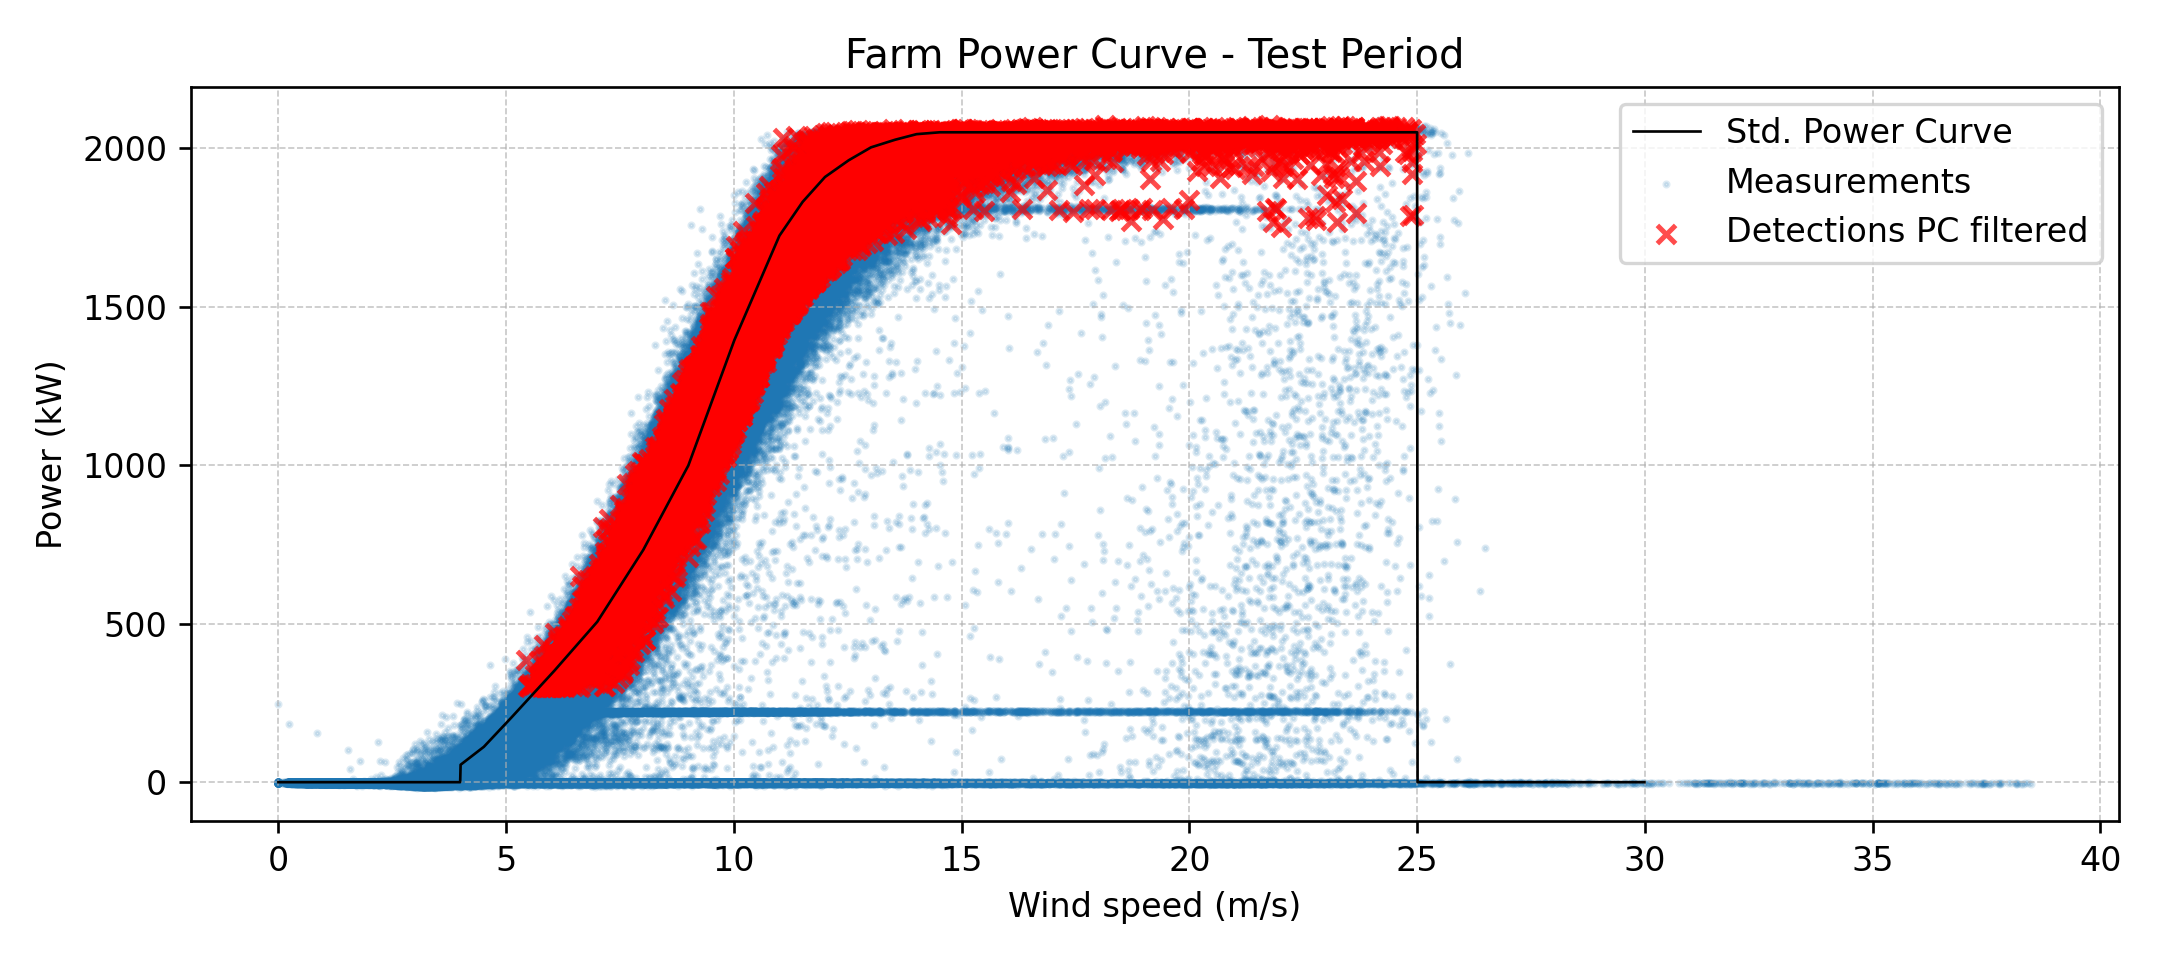

In [ ]:

pp.print_powercurve(df_pc=df_pc,
                    df_wts=p2.drop_imputations( wt_farm_df),
                    df_detections=det_points_ng,
                    detections_label=f"Detections PC filtered",
                    highlight_wt=None,
                    alpha_det=0.7
                    )

In [ ]:
raw_test[ic.TS_COL] = pd.to_datetime(raw_test[ic.TS_COL])

raw_test_pc_filtered = raw_test.merge(
    det_points_ng,
    how="inner",
    on=[ic.WT_ID, ic.TS_COL],
    validate="one_to_one"
)

In [ ]:

display(raw_test_pc_filtered.head())
print(len(raw_test))
print(len(raw_test_pc_filtered))

,WT_ID,Ambient temperature (converter) (°C),Date and time,Drive train acceleration (mm/ss),Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Gearbox speed (RPM),Generator bearing front temperature (°C),Generator bearing rear temperature (°C),Generator RPM (RPM),Hub temperature (°C),Motor current axis 1 (A),Motor current axis 2 (A),Motor current axis 3 (A),Nacelle ambient temperature (°C),Nacelle position (°),Nacelle temperature (°C),Power (kW)_x,Rotor bearing temp (°C),Rotor speed (RPM),Stator temperature 1 (°C),Temp. top box (°C),Temperature motor axis 1 (°C),Temperature motor axis 2 (°C),Temperature motor axis 3 (°C),Vane position 1+2 (°),Wind direction (°),Wind speed (m/s)_x,Blade angle (pitch position) A (°),Blade angle (pitch position) B (°),Blade angle (pitch position) C (°),Front bearing temperature (°C),Gear oil inlet temperature (°C),Gear oil temperature (°C),Rear bearing temperature (°C),Tower Acceleration X (mm/ss),Tower Acceleration Y (mm/ss),Transformer cell temperature (°C),Transformer temperature (°C),Yaw bearing angle (°),Wind speed (m/s)_y,Power (kW)_y
0,1,17.531667,2020-05-22 12:00:00,18.090195,279.324941,781.022457,1795.171242,47.595000,48.943333,1792.498241,19.408667,3.562745,3.154085,4.513072,13.511667,214.901337,18.841667,2048.663672,30.725000,17.084245,89.198333,25.798333,76.000000,76.213000,77.085667,-6.279857,208.605634,23.445591,18.630000,18.614333,18.601667,70.928333,32.913334,56.653333,61.690000,106.792612,115.462450,22.321666,93.656667,214.901337,23.445591,2048.663672
1,1,17.321666,2020-05-22 12:10:00,17.903940,282.605733,788.256964,1789.488731,48.316667,49.635000,1787.045059,19.348667,2.618791,3.802614,4.185621,13.631667,214.901337,18.723334,2020.345138,30.886667,17.033811,89.870000,25.726667,76.211000,77.071667,77.950667,-1.711593,213.798399,21.809166,16.982000,16.966667,16.965333,69.966667,32.551667,55.966667,60.936666,131.982801,91.792336,22.376667,94.823335,214.901337,21.809166,2020.345138
2,1,15.905172,2020-05-22 15:00:00,18.660976,208.402141,583.720314,1791.722019,43.627586,43.543103,1790.175255,18.441379,3.146552,3.623225,4.029919,13.267241,211.572051,17.893103,2042.129260,28.110345,17.004937,78.755172,25.600000,66.344828,70.197586,66.753448,4.109860,217.414936,22.344573,18.181724,18.190345,18.193448,72.800000,55.141380,59.155172,63.672414,138.419713,95.522478,20.494828,70.787931,211.572051,22.344573,2042.129260
3,1,16.243104,2020-05-22 16:00:00,11.288130,218.057317,616.745041,1810.431274,42.939655,44.282759,1808.324117,18.000000,2.900101,3.418864,3.929682,13.713793,215.998901,18.231035,2041.550078,27.431034,17.220277,77.087931,25.400000,63.343793,66.642414,63.070345,0.355420,214.885474,24.778329,20.947931,20.947586,20.954483,64.920690,52.303448,56.281035,60.450000,153.810435,119.921621,21.046552,68.979310,215.998901,24.778329,2041.550078
4,1,15.773333,2020-05-23 12:50:00,22.942595,236.270491,672.478516,1790.263142,42.736666,47.626667,1788.615055,17.607667,4.073529,3.856699,4.409804,12.551667,237.950195,18.521667,2034.627112,29.111667,17.015803,88.150000,23.556667,77.039333,82.271333,78.362667,4.788990,241.782143,21.400011,16.413667,16.398333,16.393333,74.330000,46.498333,58.733333,63.520000,133.929420,106.101302,19.395000,97.565000,237.950195,21.400011,2034.627112


3172316
22449


In [ ]:
raw_test_pc_filtered.to_csv(ic.PATH_PART2_DETECTIONS/ "raw_test_pc_filtered")

In [ ]:
temp_sigs = [it for it in hfn.load_feature_order() if "(°C)" in it]

In [ ]:
nbm_df = p2.build_normal_behavior_by_wind(
    train_pc_dir=ic.PATH_PC_FILTERING,
    bin_width=1.0,
    signal_cols=temp_sigs,
)

nbm_q = p2.build_normal_behavior_by_wind(
    train_pc_dir=ic.PATH_PC_FILTERING,
    bin_width=1.0,
    signal_cols=None,
    min_samples_per_bin=50,
)

nbm_df = nbm_df.merge(
    nbm_q[[
        ic.WT_ID,
        NBM_COLS.SIG_NAME.value,
        NBM_COLS.WIND_BIN_CENTER.value,
    ]],
    on=[ic.WT_ID, NBM_COLS.SIG_NAME.value, NBM_COLS.WIND_BIN_CENTER.value],
    how="left",
    validate="1:1",
)


In [ ]:
display(nbm_df)

,WT_ID,signal_name,wind_bin_center,n_samples,mean_value,std_value
0,1,Ambient temperature (converter) (°C),5.5,5306,12.063005,5.163633
1,1,Ambient temperature (converter) (°C),6.5,5261,11.944847,5.067394
2,1,Ambient temperature (converter) (°C),7.5,4260,12.733430,5.044853
3,1,Ambient temperature (converter) (°C),8.5,3048,13.204940,5.003161
4,1,Ambient temperature (converter) (°C),9.5,2464,13.056824,4.548860
...,...,...,...,...,...,...
4513,15,Transformer temperature (°C),18.5,403,97.030517,6.935819
4514,15,Transformer temperature (°C),19.5,295,97.113976,6.429111
4515,15,Transformer temperature (°C),20.5,209,96.259317,8.392887
4516,15,Transformer temperature (°C),21.5,146,94.570380,8.433471


In [ ]:
selected_detections, windows_df = p2.build_event_detections_sliding_windows_pipeline(
    eval_df=test_eval_pc_filtered,
    window_length_units=18,
    top_k= 100,
    event_half_width_units=720,
    min_overlap_ratio=0.3
)

In [ ]:
display(selected_detections.head())
print(len(selected_detections))
display(windows_df.head())


,WT_ID,Date and time,event_mean_loss,event_max_loss,uid,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C),RE_Generator RPM (RPM),RE_Hub temperature (°C),RE_Motor current axis 1 (A),RE_Motor current axis 2 (A),RE_Motor current axis 3 (A),RE_Nacelle ambient temperature (°C),RE_Nacelle position (°),RE_Nacelle temperature (°C),RE_Power (kW),RE_Rotor bearing temp (°C),RE_Rotor speed (RPM),RE_Stator temperature 1 (°C),RE_Temp. top box (°C),RE_Temperature motor axis 1 (°C),RE_Temperature motor axis 2 (°C),RE_Temperature motor axis 3 (°C),RE_Vane position 1+2 (°),RE_Wind direction (°),RE_Wind speed (m/s),RE_Blade angle (pitch position) A (°),RE_Blade angle (pitch position) B (°),RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1,2020-05-22 12:10:00,0.010265,0.116970,1590149400000000001,0.116970,0.156557,0.242914,0.285185,0.210931,0.355963,0.004074,0.009758,0.352014,0.015220,0.114377,0.229666,0.264592,0.197061,0.000054,0.012924,0.409037,0.006732,0.357298,0.007829,1.468866e-07,0.121382,0.093333,0.153743,0.007669,0.000003,0.015811,0.133073,0.137325,0.133265,0.012183,0.001328,0.039818,0.015644,0.176241,0.024396,0.146650,0.000819,8.502386e-09
1,1,2021-01-21 13:40:00,0.010880,0.159506,1611236400000000001,0.159506,0.058879,0.213196,0.283463,0.282516,0.388283,0.035612,0.019768,0.379350,0.000006,0.384360,0.128773,0.293240,0.143002,0.000007,0.027351,0.411630,0.019278,0.383773,0.237537,6.567128e-03,0.339051,0.344577,0.340940,0.009666,0.000056,0.075561,0.007876,0.007505,0.008132,0.325356,0.153456,0.235005,0.322304,0.130296,0.015191,0.010027,0.039605,3.066435e-05
2,1,2021-10-05 15:20:00,0.009619,0.093496,1633447200000000001,0.093496,0.006262,0.287523,0.205355,0.150979,0.272873,0.000549,0.005543,0.272950,0.000003,0.134782,0.132668,0.215686,0.195242,0.000006,0.009891,0.324163,0.000293,0.274002,0.013983,5.494965e-03,0.159493,0.192359,0.173037,0.007345,0.000064,0.002497,0.039412,0.042994,0.039840,0.020659,0.065013,0.044481,0.023875,0.216240,0.000285,0.000674,0.016266,7.508782e-05
3,1,2021-11-26 16:30:00,0.011742,0.123056,1637944200000000001,0.123056,0.037523,0.340805,0.117220,0.068243,0.372749,0.000140,0.006757,0.364977,0.010995,0.263621,0.203302,0.571389,0.169715,0.000007,0.013703,0.404583,0.000979,0.368487,0.001878,2.019406e-04,0.188689,0.174990,0.177003,0.003643,0.000044,0.000003,0.066843,0.067913,0.066116,0.047148,0.103836,0.067263,0.040693,0.123333,0.185998,0.044116,0.001109,1.156444e-04
4,1,2022-02-18 16:30:00,0.011795,0.157515,1645201800000000001,0.157515,0.003124,0.340476,0.247151,0.183441,0.366900,0.000032,0.001481,0.377049,0.015328,0.440018,0.242246,0.384073,0.236283,0.000166,0.008283,0.434813,0.022350,0.373796,0.039271,2.643211e-03,0.299413,0.283976,0.264559,0.005780,0.000221,0.029414,0.157280,0.166971,0.157061,0.095761,0.129719,0.119103,0.090341,0.411251,0.000070,0.020739,0.034756,2.225965e-04


79


,WT_ID,Date and time,event_mean_loss,event_max_loss,window_start,window_end
0,1,2020-05-22 12:10:00,0.010265,0.116970,2020-05-17 15:10:00,2020-05-27 15:10:00
1,1,2021-01-21 13:40:00,0.010880,0.159506,2021-01-11 02:10:00,2021-01-26 15:00:00
2,1,2021-10-05 15:20:00,0.009619,0.093496,2021-09-30 15:00:00,2021-10-10 16:20:00
3,1,2021-11-26 16:30:00,0.011742,0.123056,2021-11-21 14:00:00,2021-12-04 15:20:00
4,1,2022-02-18 16:30:00,0.011795,0.157515,2022-02-13 14:30:00,2022-02-23 17:50:00


In [ ]:
#windows_df.reset_index()
windows_df.to_csv(ic.PATH_PART2_DETECTIONS / "windows_re.csv", index=False)

In [ ]:
cat_df = p2.build_detection_catalog_signals(
    eval_df=test_eval_df,
    raw_test_df=raw_test,
    selected_detections=selected_detections,
    windows_df=windows_df,
    nbm_df = nbm_df,
    bin_width=1.0,
    top_n_signals=10,
    train_pc_dir=ic.PATH_PC_FILTERING
    
)
display(cat_df)

,WT_ID,re_at_ts,Date and time,signal_name,window_start,window_end,wind_center,n_baseline,mean_baseline,std_baseline,mean_event,std_event,value_at_ts,delta_at_ts,z_at_ts,delta_mean,z_shift
0,1,0.571389,2021-11-26 16:30:00,Motor current axis 3 (A),2021-11-21 14:00:00,2021-12-04 15:20:00,22.5,0,NaN,NaN,3.328320,1.595725,5.570425,NaN,NaN,NaN,NaN
1,1,0.528896,2022-06-09 16:20:00,Gear oil pump pressure (bar),2022-06-04 15:00:00,2022-06-14 22:40:00,10.5,0,NaN,NaN,368.570044,363.203555,798.720174,NaN,NaN,NaN,NaN
2,1,0.525480,2022-06-09 16:20:00,Gear oil inlet pressure (bar),2022-06-04 15:00:00,2022-06-14 22:40:00,10.5,0,NaN,NaN,130.816751,129.076437,282.769109,NaN,NaN,NaN,NaN
3,1,0.440018,2022-02-18 16:30:00,Motor current axis 1 (A),2022-02-13 14:30:00,2022-02-23 17:50:00,20.5,0,NaN,NaN,2.316153,1.899734,4.291503,NaN,NaN,NaN,NaN
4,1,0.434813,2022-02-18 16:30:00,Power (kW),2022-02-13 14:30:00,2022-02-23 17:50:00,20.5,0,NaN,NaN,1345.619711,970.254785,2025.708219,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,15,0.146783,2022-12-06 11:30:00,Nacelle ambient temperature (°C),2022-11-27 07:50:00,2022-12-07 08:50:00,15.5,631,8.244857,3.475829,4.172778,0.292643,3.840000,-4.404857,-1.267282,-4.072079,-1.171542
786,15,0.138960,2022-12-06 11:30:00,Tower Acceleration Y (mm/ss),2022-11-27 07:50:00,2022-12-07 08:50:00,15.5,0,NaN,NaN,59.646406,15.136404,76.737351,NaN,NaN,NaN,NaN
787,15,0.073976,2022-12-06 11:30:00,Gear oil inlet temperature (°C),2022-11-27 07:50:00,2022-12-07 08:50:00,15.5,631,37.646228,6.928204,37.629949,7.393020,30.078333,-7.567895,-1.092331,-0.016280,-0.002350
788,15,0.061369,2022-12-06 11:30:00,Vane position 1+2 (°),2022-11-27 07:50:00,2022-12-07 08:50:00,15.5,0,NaN,NaN,-3.818978,3.574530,0.186122,NaN,NaN,NaN,NaN


In [ ]:

cat_df.to_csv(ic.PATH_PART2_DETECTIONS / "catalog.csv", index=False)